# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah 'Coffee Bean Dataset Resized (224 X 224)' yang bersumber dari Kaggle. Dataset ini berisi data gambar jenis-jenis biji kopi berdasarkan warnanya yang dibagi menjadi 4 kelas

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
#Type your code here
import os, shutil
from random import sample
import shutil
from shutil import copyfile
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
os.makedirs('coffeebeans', exist_ok=True)

In [9]:
!kaggle datasets download -d gpiosenka/coffee-bean-dataset-resized-224-x-224
!unzip coffee-bean-dataset-resized-224-x-224.zip

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224
License(s): CC-BY-SA-4.0
100% 144M/144M [00:00<00:00, 194MB/s]

Archive:  coffee-bean-dataset-resized-224-x-224.zip
  inflating: Coffee Bean.csv         
  inflating: test/Dark/dark (1).png  
  inflating: test/Dark/dark (10).png  
  inflating: test/Dark/dark (100).png  
  inflating: test/Dark/dark (11).png  
  inflating: test/Dark/dark (12).png  
  inflating: test/Dark/dark (13).png  
  inflating: test/Dark/dark (14).png  
  inflating: test/Dark/dark (15).png  
  inflating: test/Dark/dark (16).png  
  inflating: test/Dark/dark (17).png  
  inflating: test/Dark/dark (18).png  
  inflating: test/Dark/dark (19).png  
  inflating: test/Dark/dark (2).png  
  inflating: test/Dark/dark (20).png  
  inflating: test/Dark/dark (21).png  
  inflating: test/Dark/dark (22).png  
  inflating: test/Dark/dark (23).png  
  inflating: test/Dark/dark (24).png  
  inflating: test/Dark/dark (25).png  
  inflating: 

In [10]:
# Source directories (from unzipped content)
source_train = '/content/train'
source_test = '/content/test'

# Destination directory (the combined_dir)
destination_dir = '/content/coffeebeans'

# Move the 'train' folder
shutil.move(source_train, destination_dir)
print(f"Moved '{source_train}' to '{destination_dir}'")

# Move the 'test' folder
shutil.move(source_test, destination_dir)
print(f"Moved '{source_test}' to '{destination_dir}'")

Moved '/content/train' to '/content/coffeebeans'
Moved '/content/test' to '/content/coffeebeans'


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
#Type your code here
def count_files(folderpath):
  coffee_classes_dict = {}
  for class_name in os.listdir(folderpath):
    files =[]
    for file in os.listdir(os.path.join(folderpath, class_name)):
      files.append(file)
    coffee_classes_dict[class_name] = len(files)
  return coffee_classes_dict

train_classes = count_files("/content/coffeebeans/train")
test_classes = count_files("/content/coffeebeans/test")

train_classes_df = pd.DataFrame(list(train_classes.items()), columns=['Class', 'Count'])
test_classes_df = pd.DataFrame(list(test_classes.items()), columns=['Class', 'Count'])

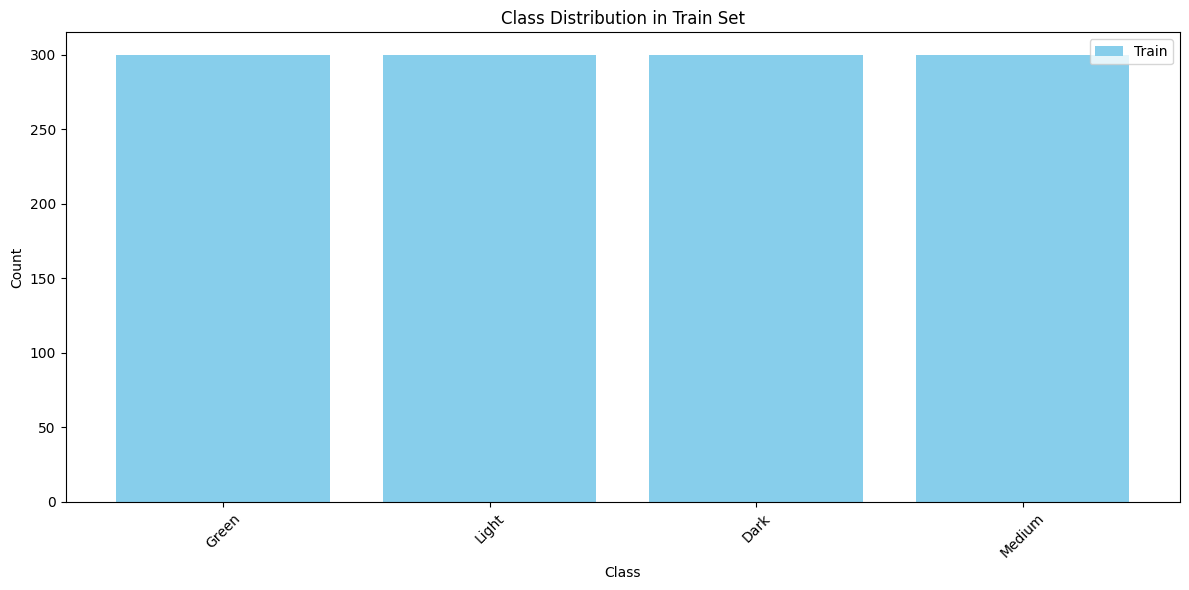

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(train_classes_df['Class'], train_classes_df['Count'], label='Train', color='skyblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Train Set')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

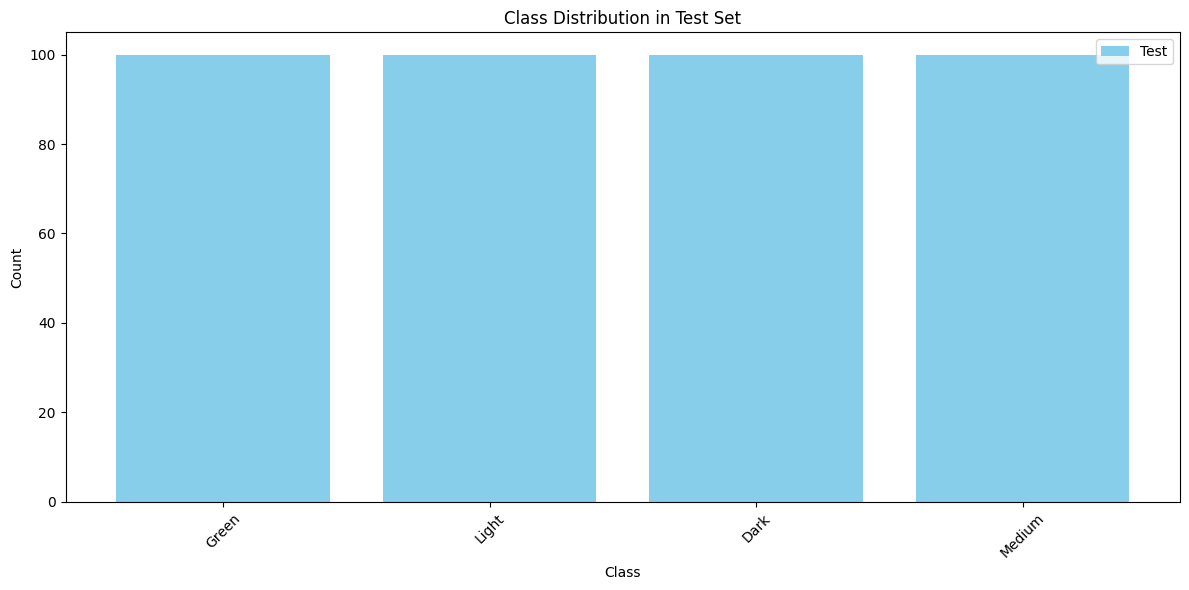

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(test_classes_df['Class'], test_classes_df['Count'], label='Test', color='skyblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Test Set')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
TRAIN_DIR = '/content/coffeebeans/train'
VAL_DIR = '/content/coffeebeans/test'

checkpoint_dir_train = os.path.join(TRAIN_DIR, '.ipynb_checkpoints')
checkpoint_dir_val = os.path.join(VAL_DIR, '.ipynb_checkpoints')

if os.path.exists(checkpoint_dir_train):
    shutil.rmtree(checkpoint_dir_train)
    print(f"Removed: {checkpoint_dir_train}")

if os.path.exists(checkpoint_dir_val):
    shutil.rmtree(checkpoint_dir_val)
    print(f"Removed: {checkpoint_dir_val}")

# Memastikan direktori ada sebelum digunakan oleh generator
# Catatan: Kode augmentasi sebelumnya harus sudah memindahkan file ke folder kategori di sini
if not os.path.exists(TRAIN_DIR):
    print(f"Peringatan: Folder {TRAIN_DIR} tidak ditemukan. Pastikan proses augmentasi di sel sebelumnya sudah selesai.")

# ImageDataGenerator dengan augmentasi sederhana
datagen = ImageDataGenerator(
    rescale=1/255.,
    validation_split=0.3
)

test_datagen = ImageDataGenerator(rescale=1./255)

try:
    train_generator = datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(150, 150),
        batch_size=128,
        color_mode='grayscale',
        class_mode='categorical',
        subset='training',
        shuffle=True
    )

    validation_generator = datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(150, 150),
        batch_size=128,
        color_mode='grayscale',
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )

    test_generator = test_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(150, 150),
        batch_size=128,
        color_mode='grayscale', # Disamakan dengan training (grayscale)
        class_mode='categorical',
        shuffle=False
    )
except Exception as e:
    print(f"Error saat memuat generator: {e}\nPastikan data augmentasi sudah tersusun dalam folder kategori (misal: train_augmented/cats/)")

Found 840 images belonging to 4 classes.
Found 360 images belonging to 4 classes.
Found 400 images belonging to 4 classes.


In [15]:
def save_preprocessed_images_from_generator(generator, output_base_dir, max_images_per_class=None):
    """
    Saves images and their labels from a Keras ImageDataGenerator to specified
    output directories, maintaining the class structure.
    Images are denormalized (multiplied by 255) and converted to uint8.

    Args:
        generator: An instance of ImageDataGenerator (e.g., train_generator).
        output_base_dir: The root directory where preprocessed images will be saved.
                         e.g., 'preprocessed_data/train'
        max_images_per_class: Optional. The maximum number of images to save per class.
                              If None, all images from the generator are saved.
    """
    print(f"Preparing to save images to: {output_base_dir}")

    # Get class labels mapping from the generator
    class_indices = generator.class_indices
    idx_to_class = {v: k for k, v in class_indices.items()}

    # Create base output directory if it doesn't exist
    os.makedirs(output_base_dir, exist_ok=True)

    # Create class subdirectories
    for class_name in class_indices.keys():
        os.makedirs(os.path.join(output_base_dir, class_name), exist_ok=True)

    saved_counts = {class_name: 0 for class_name in class_indices.keys()}
    total_saved_images = 0

    print(f"Saving images from generator to {output_base_dir}...")

    # Iterate through the generator for one full pass (or until max_images_per_class is met).
    num_batches = len(generator)
    for i in range(num_batches):
        batch_images, batch_labels = next(generator) # Get the next batch

        for img_array, label_one_hot in zip(batch_images, batch_labels):
            class_idx = np.argmax(label_one_hot)
            class_name = idx_to_class[class_idx]

            if max_images_per_class is not None and saved_counts[class_name] >= max_images_per_class:
                continue # Skip if we've saved enough for this class

            # Denormalize (if scaled 0-1) and convert to uint8
            img_array_denorm = (img_array * 255).astype(np.uint8)

            # Handle grayscale vs. RGB
            if img_array_denorm.shape[-1] == 1: # Grayscale
                img_array_denorm = np.squeeze(img_array_denorm, axis=-1)
                img = Image.fromarray(img_array_denorm, mode='L')
            else: # RGB
                img = Image.fromarray(img_array_denorm)

            filename = f"{class_name}_{saved_counts[class_name]}.png"
            filepath = os.path.join(output_base_dir, class_name, filename)
            img.save(filepath)

            saved_counts[class_name] += 1
            total_saved_images += 1

        # Check if all classes have reached their max_images_per_class (if specified)
        if max_images_per_class is not None and all(count >= max_images_per_class for count in saved_counts.values()):
            break

    print(f"Finished saving. Total images saved: {total_saved_images}")
    for class_name, count in saved_counts.items():
        print(f"  {class_name}: {count} images saved.")

In [16]:
# Define output directories for the preprocessed images
output_base_dir = '/content/preprocessed_coffeebeans'
output_train_dir = os.path.join(output_base_dir, 'train')
output_validation_dir = os.path.join(output_base_dir, 'validation')
output_test_dir = os.path.join(output_base_dir, 'test')

# Save images from the train generator
save_preprocessed_images_from_generator(train_generator, output_train_dir)

# Save images from the validation generator
save_preprocessed_images_from_generator(validation_generator, output_validation_dir)

# Save images from the test generator
save_preprocessed_images_from_generator(test_generator, output_test_dir)

Preparing to save images to: /content/preprocessed_coffeebeans/train
Saving images from generator to /content/preprocessed_coffeebeans/train...


/tmp/ipykernel_16632/171692794.py:50: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array_denorm, mode='L')


Finished saving. Total images saved: 840
  Dark: 210 images saved.
  Green: 210 images saved.
  Light: 210 images saved.
  Medium: 210 images saved.
Preparing to save images to: /content/preprocessed_coffeebeans/validation
Saving images from generator to /content/preprocessed_coffeebeans/validation...
Finished saving. Total images saved: 360
  Dark: 90 images saved.
  Green: 90 images saved.
  Light: 90 images saved.
  Medium: 90 images saved.
Preparing to save images to: /content/preprocessed_coffeebeans/test
Saving images from generator to /content/preprocessed_coffeebeans/test...
Finished saving. Total images saved: 400
  Dark: 100 images saved.
  Green: 100 images saved.
  Light: 100 images saved.
  Medium: 100 images saved.
